# Informer Model for K8s Pod Count Prediction

In [1]:
%pip install pandas numpy scikit-learn tensorflow matplotlib seaborn keras-tuner -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import math
import warnings
from itertools import product
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

## Data Loading and Exploration

In [3]:
df = pd.read_csv('sample_data/data.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed', dayfirst=False)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Services: {df['service_id'].unique()}")
df.head()

Dataset shape: (43200, 23)
Date range: 2025-11-01 00:00:00 to 2025-11-30 23:59:00
Services: ['Order']


,timestamp,service_id,current_pod_count,request_rate_rps,latency_p95_ms,latency_p99_ms,error_rate_percent,queue_length,pod_cpu_usage_percent_avg,pod_cpu_usage_percent_p95,...,hour_cos,day_sin,day_cos,mesh_inbound_rps,mesh_inbound_latency_p95,mesh_inbound_error_rate,degree_centrality,eigenvector_centrality,betweenness_centrality,closeness_centrality
0,2025-11-01 00:00:00,Order,2,73.30,85.09,111.69,0.0360,0.0,26.36,30.07,...,1.0,-0.9749,-0.2225,71.99,83.33,0.0371,0.8313,0.8591,0.6531,0.7367
1,2025-11-01 00:01:00,Order,2,75.69,93.87,131.05,0.0361,0.0,29.32,33.63,...,1.0,-0.9749,-0.2225,74.63,88.76,0.0341,0.7970,0.8745,0.6764,0.7216
2,2025-11-01 00:02:00,Order,2,79.28,91.01,123.72,0.0363,0.0,28.98,34.94,...,1.0,-0.9749,-0.2225,79.07,84.48,0.0343,0.8088,0.8933,0.6303,0.7102
3,2025-11-01 00:03:00,Order,2,81.81,84.87,103.11,0.0364,0.0,33.21,38.83,...,1.0,-0.9749,-0.2225,81.46,82.47,0.0397,0.7837,0.8883,0.6635,0.7434
4,2025-11-01 00:04:00,Order,2,81.72,80.07,99.22,0.0364,0.0,30.64,35.01,...,1.0,-0.9749,-0.2225,79.50,78.01,0.0378,0.8163,0.8750,0.6596,0.7066


In [4]:
SERVICE_NAME = 'Order'
df_service = df[df['service_id'] == SERVICE_NAME].copy()
df_service = df_service.sort_values('timestamp').reset_index(drop=True)

print(f"{SERVICE_NAME} service: {df_service.shape[0]} records")
print(f"Time range: {df_service['timestamp'].min()} to {df_service['timestamp'].max()}")
df_service.head(10)

Order service: 43200 records
Time range: 2025-11-01 00:00:00 to 2025-11-30 23:59:00


,timestamp,service_id,current_pod_count,request_rate_rps,latency_p95_ms,latency_p99_ms,error_rate_percent,queue_length,pod_cpu_usage_percent_avg,pod_cpu_usage_percent_p95,...,hour_cos,day_sin,day_cos,mesh_inbound_rps,mesh_inbound_latency_p95,mesh_inbound_error_rate,degree_centrality,eigenvector_centrality,betweenness_centrality,closeness_centrality
0,2025-11-01 00:00:00,Order,2,73.30,85.09,111.69,0.0360,0.0,26.36,30.07,...,1.0,-0.9749,-0.2225,71.99,83.33,0.0371,0.8313,0.8591,0.6531,0.7367
1,2025-11-01 00:01:00,Order,2,75.69,93.87,131.05,0.0361,0.0,29.32,33.63,...,1.0,-0.9749,-0.2225,74.63,88.76,0.0341,0.7970,0.8745,0.6764,0.7216
2,2025-11-01 00:02:00,Order,2,79.28,91.01,123.72,0.0363,0.0,28.98,34.94,...,1.0,-0.9749,-0.2225,79.07,84.48,0.0343,0.8088,0.8933,0.6303,0.7102
3,2025-11-01 00:03:00,Order,2,81.81,84.87,103.11,0.0364,0.0,33.21,38.83,...,1.0,-0.9749,-0.2225,81.46,82.47,0.0397,0.7837,0.8883,0.6635,0.7434
4,2025-11-01 00:04:00,Order,2,81.72,80.07,99.22,0.0364,0.0,30.64,35.01,...,1.0,-0.9749,-0.2225,79.50,78.01,0.0378,0.8163,0.8750,0.6596,0.7066
5,2025-11-01 00:05:00,Order,2,79.54,77.05,107.67,0.0363,0.0,33.51,41.81,...,1.0,-0.9749,-0.2225,81.78,73.01,0.0386,0.8339,0.8999,0.6665,0.7213
6,2025-11-01 00:06:00,Order,2,76.77,74.74,92.30,0.0361,0.0,31.61,38.97,...,1.0,-0.9749,-0.2225,74.91,70.94,0.0337,0.7788,0.8963,0.6463,0.7154
7,2025-11-01 00:07:00,Order,2,73.14,68.89,83.51,0.0358,0.0,31.90,37.61,...,1.0,-0.9749,-0.2225,73.55,66.46,0.0359,0.8154,0.8885,0.6172,0.7499
8,2025-11-01 00:08:00,Order,2,67.87,65.17,80.54,0.0355,0.0,30.97,36.11,...,1.0,-0.9749,-0.2225,68.22,62.69,0.0360,0.8420,0.8913,0.6731,0.7258
9,2025-11-01 00:09:00,Order,2,63.85,65.07,83.15,0.0353,0.0,27.89,34.60,...,1.0,-0.9749,-0.2225,63.34,61.92,0.0335,0.8200,0.8779,0.6477,0.7490


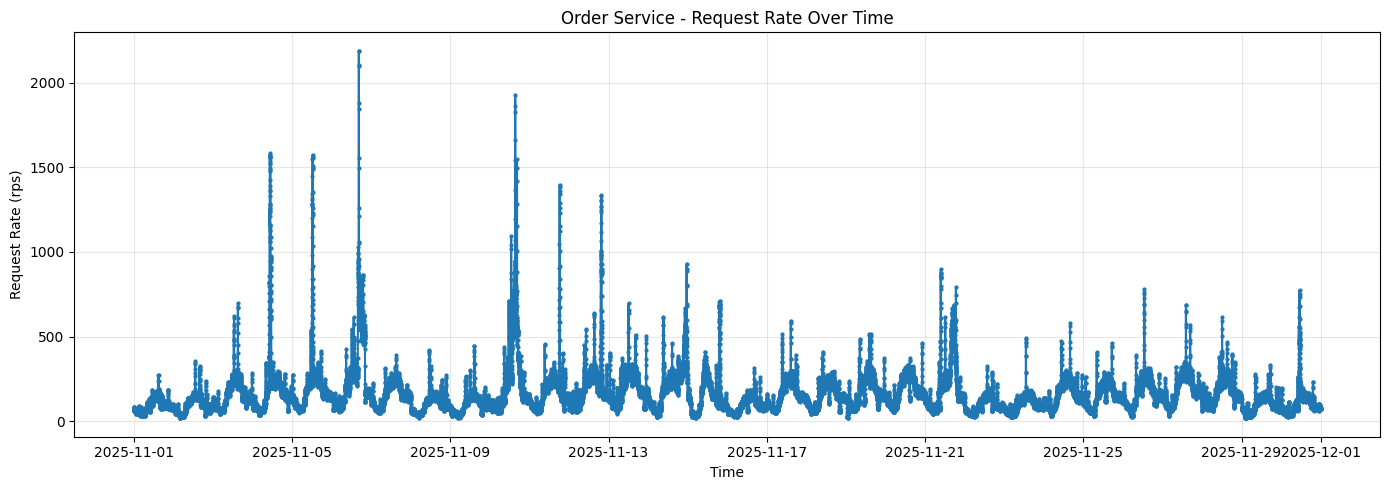

count    43200.000000
mean       160.078258
std        123.435016
min         17.590000
25%         85.330000
50%        136.545000
75%        204.012500
max       2187.940000
Name: request_rate_rps, dtype: float64


In [5]:
plt.figure(figsize=(14, 5))
plt.plot(df_service['timestamp'], df_service['request_rate_rps'], marker='o', markersize=2)
plt.title(f'{SERVICE_NAME} Service - Request Rate Over Time')
plt.xlabel('Time')
plt.ylabel('Request Rate (rps)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(df_service['request_rate_rps'].describe())

## Data Diagnostics

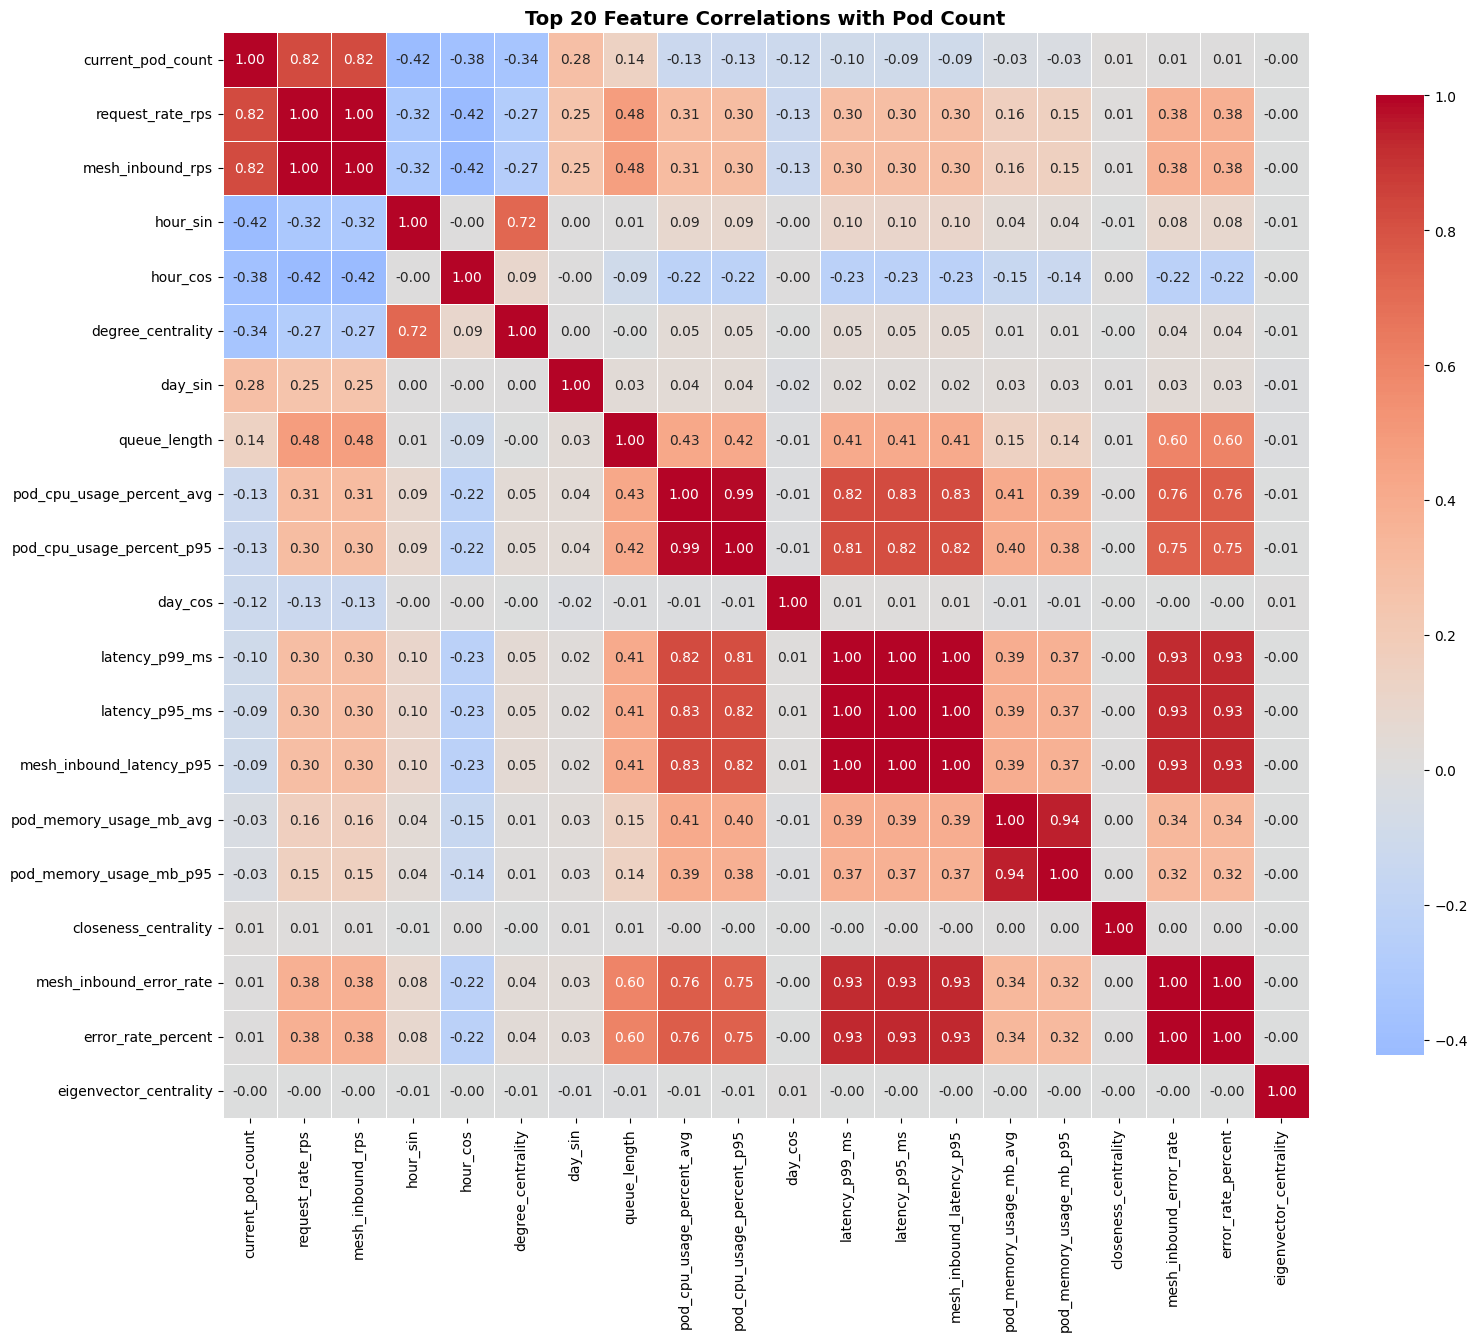

Top correlations with current_pod_count:
  + request_rate_rps                        : 0.8179
  + mesh_inbound_rps                        : 0.8176
  - hour_sin                                : 0.4158
  - hour_cos                                : 0.3767
  - degree_centrality                       : 0.3405
  + day_sin                                 : 0.2838
  + queue_length                            : 0.1395
  - pod_cpu_usage_percent_avg               : 0.1273
  - pod_cpu_usage_percent_p95               : 0.1254
  - day_cos                                 : 0.1217
  - latency_p99_ms                          : 0.0953
  - latency_p95_ms                          : 0.0948
  - mesh_inbound_latency_p95                : 0.0945
  - pod_memory_usage_mb_avg                 : 0.0304
  - pod_memory_usage_mb_p95                 : 0.0277


In [6]:
numeric_cols = df_service.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['timestamp', 'service_id']]

corr_matrix = df_service[numeric_cols].corr()

plt.figure(figsize=(16, 14))
top_features = corr_matrix['current_pod_count'].abs().sort_values(ascending=False).head(20).index
sns.heatmap(df_service[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Top 20 Feature Correlations with Pod Count', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("Top correlations with current_pod_count:")
top_corr = corr_matrix['current_pod_count'].abs().sort_values(ascending=False).head(16)
for feature, corr_value in top_corr.items():
    if feature != 'current_pod_count':
        sign = '+' if corr_matrix['current_pod_count'][feature] > 0 else '-'
        print(f"  {sign} {feature:40s}: {abs(corr_value):.4f}")

In [7]:
missing = df_service.isnull().sum()
print(f"Missing values: {missing.sum()}")
if missing.sum() > 0:
    print(missing[missing > 0])

constant_features = [col for col in numeric_cols if df_service[col].nunique() == 1]
print(f"Constant features: {constant_features if constant_features else 'None'}")

print(f"Dataset size: {len(df_service):,} samples")
print(f"Time span: {(df_service['timestamp'].max() - df_service['timestamp'].min()).days} days")

Missing values: 0
Constant features: None
Dataset size: 43,200 samples
Time span: 29 days


## Configuration

In [8]:
# Device setup
if tf.config.list_physical_devices('GPU'):
    DEVICE_TYPE = 'GPU'
    strategy = tf.distribute.MirroredStrategy()
else:
    DEVICE_TYPE = 'CPU'
    strategy = tf.distribute.OneDeviceStrategy(device='/cpu:0')
print(f'Running on {DEVICE_TYPE}')

# Training parameters
LOOKBACK = 20 if DEVICE_TYPE == 'CPU' else 30
PREDICTION_HORIZON = 5
EPOCHS = 300
BATCH_SIZE = 128
LEARNING_RATE = 0.00027084489969062176
GRADIENT_CLIP_NORM = 1.0
EARLY_STOPPING_PATIENCE = 40
REDUCE_LR_PATIENCE = 20

# Loss configuration
USE_ASYMMETRIC_LOSS = True
UNDER_PRED_PENALTY = 3.0
OVER_PRED_PENALTY = 0.8
TARGET_WEIGHTS = np.array([1.5, 1.2, 1.0], dtype=np.float32)

# HPA parameters
TARGET_RPS_PER_POD = 60.0
TARGET_CPU_UTIL = 55.0

# Model architecture
MODEL_CONFIG = {
    'd_model': 128,
    'num_heads': 16,
    'num_layers': 5,
    'dff': 512,
    'dropout_rate': 0.1,
    'activation': 'gelu'
}

HYPERPARAMETER_TUNING = False
USE_OPTIMIZED_CONFIG = True

print(f"Lookback: {LOOKBACK}, Horizon: {PREDICTION_HORIZON}, Epochs: {EPOCHS}")

Running on GPU
Lookback: 30, Horizon: 5, Epochs: 300


## Data Preprocessing

In [9]:
# Create future metric targets
df_service['future_request_rate_rps'] = df_service['request_rate_rps'].shift(-PREDICTION_HORIZON)
df_service['future_pod_cpu_usage_percent_avg'] = df_service['pod_cpu_usage_percent_avg'].shift(-PREDICTION_HORIZON)
df_service['future_latency_p95_ms'] = df_service['latency_p95_ms'].shift(-PREDICTION_HORIZON)

df_service = df_service[:-PREDICTION_HORIZON].copy()
print(f"Dataset shape after creating targets: {df_service.shape}")

Dataset shape after creating targets: (43195, 26)


In [10]:
# Lag features
for lag in [1, 2, 3, 5, 10]:
    df_service[f'pod_count_lag_{lag}'] = df_service['current_pod_count'].shift(lag)
    df_service[f'request_rate_lag_{lag}'] = df_service['request_rate_rps'].shift(lag)
    df_service[f'cpu_lag_{lag}'] = df_service['pod_cpu_usage_percent_avg'].shift(lag)

# Rolling statistics
for window in [5, 10, 20]:
    df_service[f'pod_count_rolling_mean_{window}'] = df_service['current_pod_count'].rolling(window=window, min_periods=1).mean()
    df_service[f'pod_count_rolling_std_{window}'] = df_service['current_pod_count'].rolling(window=window, min_periods=1).std()
    df_service[f'request_rate_rolling_mean_{window}'] = df_service['request_rate_rps'].rolling(window=window, min_periods=1).mean()
    df_service[f'cpu_rolling_mean_{window}'] = df_service['pod_cpu_usage_percent_avg'].rolling(window=window, min_periods=1).mean()

# Rate of change features
df_service['pod_count_diff'] = df_service['current_pod_count'].diff()
df_service['request_rate_diff'] = df_service['request_rate_rps'].diff()
df_service['cpu_diff'] = df_service['pod_cpu_usage_percent_avg'].diff()

df_service = df_service.fillna(method='bfill').fillna(method='ffill')
print(f"Basic features created. Shape: {df_service.shape}")

Basic features created. Shape: (43195, 56)


## Advanced Feature Engineering

In [11]:
# Exponential Moving Averages
df_service['request_rate_ema_5'] = df_service['request_rate_rps'].ewm(span=5, adjust=False).mean()
df_service['request_rate_ema_15'] = df_service['request_rate_rps'].ewm(span=15, adjust=False).mean()
df_service['cpu_ema_5'] = df_service['pod_cpu_usage_percent_avg'].ewm(span=5, adjust=False).mean()
df_service['cpu_ema_15'] = df_service['pod_cpu_usage_percent_avg'].ewm(span=15, adjust=False).mean()
df_service['latency_ema_5'] = df_service['latency_p95_ms'].ewm(span=5, adjust=False).mean()

# Interaction features
df_service['load_factor'] = df_service['request_rate_rps'] * df_service['pod_cpu_usage_percent_avg']
df_service['memory_pressure'] = df_service['pod_memory_usage_mb_avg'] / (df_service['current_pod_count'] + 1)
df_service['requests_per_pod'] = df_service['request_rate_rps'] / (df_service['current_pod_count'] + 1)
df_service['cpu_per_request'] = df_service['pod_cpu_usage_percent_avg'] / (df_service['request_rate_rps'] + 1)
df_service['error_latency_product'] = df_service['error_rate_percent'] * df_service['latency_p95_ms']

# Ratios
df_service['cpu_to_memory_ratio'] = df_service['pod_cpu_usage_percent_avg'] / (df_service['pod_memory_usage_mb_avg'] + 1)
df_service['p95_to_avg_cpu_ratio'] = df_service['pod_cpu_usage_percent_p95'] / (df_service['pod_cpu_usage_percent_avg'] + 1)
df_service['inbound_to_outbound_ratio'] = df_service['mesh_inbound_rps'] / (df_service['request_rate_rps'] + 1)

# Acceleration
df_service['request_rate_acceleration'] = df_service['request_rate_diff'].diff()
df_service['cpu_acceleration'] = df_service['cpu_diff'].diff()

# Rolling min/max
for window in [5, 10]:
    df_service[f'request_rate_rolling_max_{window}'] = df_service['request_rate_rps'].rolling(window=window, min_periods=1).max()
    df_service[f'cpu_rolling_max_{window}'] = df_service['pod_cpu_usage_percent_avg'].rolling(window=window, min_periods=1).max()
    df_service[f'latency_rolling_max_{window}'] = df_service['latency_p95_ms'].rolling(window=window, min_periods=1).max()

# Trend indicators
df_service['request_rate_trend_5'] = df_service['request_rate_rps'] - df_service['request_rate_ema_5']
df_service['cpu_trend_5'] = df_service['pod_cpu_usage_percent_avg'] - df_service['cpu_ema_5']

# Volatility
df_service['request_rate_volatility'] = df_service['request_rate_rps'].rolling(window=10, min_periods=1).std() / (df_service['request_rate_ema_5'] + 1)
df_service['cpu_volatility'] = df_service['pod_cpu_usage_percent_avg'].rolling(window=10, min_periods=1).std() / (df_service['cpu_ema_5'] + 1)

# Cumulative sum
df_service['request_rate_cumsum_10'] = df_service['request_rate_diff'].rolling(window=10, min_periods=1).sum()
df_service['cpu_cumsum_10'] = df_service['cpu_diff'].rolling(window=10, min_periods=1).sum()

# Network centrality interactions
df_service['centrality_load'] = df_service['degree_centrality'] * df_service['mesh_inbound_rps']
df_service['betweenness_requests'] = df_service['betweenness_centrality'] * df_service['request_rate_rps']

df_service = df_service.fillna(method='bfill').fillna(method='ffill').fillna(0)
print(f"Advanced features created. Shape: {df_service.shape}")

Advanced features created. Shape: (43195, 85)


In [12]:
base_feature_cols = [
    'current_pod_count', 'request_rate_rps', 'latency_p95_ms', 'error_rate_percent',
    'queue_length', 'pod_cpu_usage_percent_avg', 'pod_cpu_usage_percent_p95',
    'pod_memory_usage_mb_avg', 'pod_memory_usage_mb_p95', 'mesh_inbound_rps',
    'mesh_inbound_latency_p95', 'mesh_inbound_error_rate', 'degree_centrality',
    'eigenvector_centrality', 'betweenness_centrality', 'closeness_centrality',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos'
]

engineered_patterns = ['lag_', 'rolling_', 'diff', 'ema_', 'factor', 'pressure',
                       'per_pod', 'per_request', 'product', 'ratio',
                       'acceleration', 'trend_', 'volatility', 'cumsum',
                       'centrality_load', 'betweenness_requests']

engineered_cols = [col for col in df_service.columns
                   if any(pattern in col for pattern in engineered_patterns)]

feature_cols = base_feature_cols + engineered_cols

target_cols = ['future_request_rate_rps', 'future_pod_cpu_usage_percent_avg', 'future_latency_p95_ms']

print(f"Features: {len(feature_cols)} (Base: {len(base_feature_cols)}, Engineered: {len(engineered_cols)})")
print(f"Targets: {target_cols}")

Features: 79 (Base: 20, Engineered: 59)
Targets: ['future_request_rate_rps', 'future_pod_cpu_usage_percent_avg', 'future_latency_p95_ms']


In [13]:
# Handle missing values
missing_counts = df_service[feature_cols + target_cols].isnull().sum()
if missing_counts.sum() > 0:
    df_service[feature_cols] = df_service[feature_cols].fillna(method='ffill').fillna(method='bfill').fillna(0)
    df_service[target_cols] = df_service[target_cols].fillna(method='ffill').fillna(method='bfill').fillna(0)

print(f"Dataset ready: {df_service.shape}, Features: {len(feature_cols)}, Targets: {len(target_cols)}")

Dataset ready: (43195, 85), Features: 79, Targets: 3


## Train/Validation/Test Split

In [14]:
train_size = int(0.70 * len(df_service))
val_size = int(0.15 * len(df_service))

train_df = df_service[:train_size].copy()
val_df = df_service[train_size:train_size + val_size].copy()
test_df = df_service[train_size + val_size:].copy()

print(f"Train: {len(train_df)} ({len(train_df)/len(df_service)*100:.1f}%)")
print(f"Validation: {len(val_df)} ({len(val_df)/len(df_service)*100:.1f}%)")
print(f"Test: {len(test_df)} ({len(test_df)/len(df_service)*100:.1f}%)")

Train: 30236 (70.0%)
Validation: 6479 (15.0%)
Test: 6480 (15.0%)


In [15]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

scaler_X.fit(train_df[feature_cols])
scaler_y.fit(train_df[target_cols])

train_X_scaled = scaler_X.transform(train_df[feature_cols])
train_y_scaled = scaler_y.transform(train_df[target_cols])

val_X_scaled = scaler_X.transform(val_df[feature_cols])
val_y_scaled = scaler_y.transform(val_df[target_cols])

test_X_scaled = scaler_X.transform(test_df[feature_cols])
test_y_scaled = scaler_y.transform(test_df[target_cols])

print(f"Train X: {train_X_scaled.shape}, Train y: {train_y_scaled.shape}")

Train X: (30236, 79), Train y: (30236, 3)


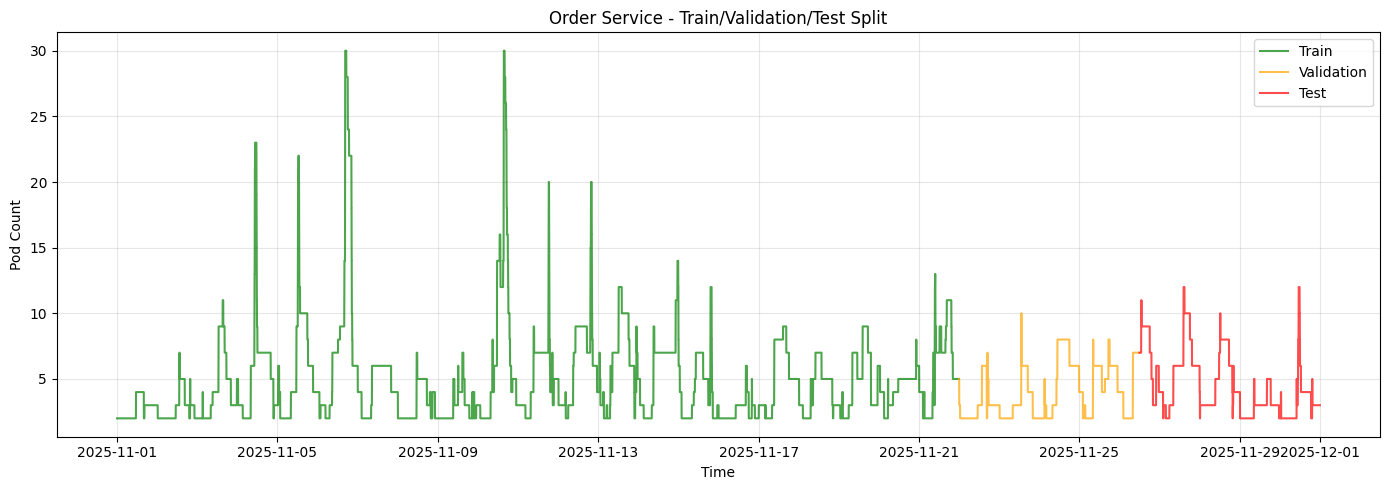

In [16]:
plt.figure(figsize=(14, 5))
plt.plot(train_df['timestamp'], train_df['current_pod_count'], label='Train', color='green', alpha=0.7)
plt.plot(val_df['timestamp'], val_df['current_pod_count'], label='Validation', color='orange', alpha=0.7)
plt.plot(test_df['timestamp'], test_df['current_pod_count'], label='Test', color='red', alpha=0.7)
plt.title(f'{SERVICE_NAME} Service - Train/Validation/Test Split')
plt.xlabel('Time')
plt.ylabel('Pod Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Sequence Generation

In [17]:
def create_sequences(X, y, lookback=10):
    """Create sequences for time-series prediction with multi-output targets."""
    X_seq, y_seq = [], []
    for i in range(len(X) - lookback):
        X_seq.append(X[i:i + lookback])
        y_seq.append(y[i + lookback])
    return np.array(X_seq), np.array(y_seq)

print(f"Lookback: {LOOKBACK} timesteps, Device: {DEVICE_TYPE}")

Lookback: 30 timesteps, Device: GPU


In [18]:
X_train_seq, y_train_seq = create_sequences(train_X_scaled, train_y_scaled, lookback=LOOKBACK)
X_val_seq, y_val_seq = create_sequences(val_X_scaled, val_y_scaled, lookback=LOOKBACK)
X_test_seq, y_test_seq = create_sequences(test_X_scaled, test_y_scaled, lookback=LOOKBACK)

print(f"Train: {X_train_seq.shape}, Val: {X_val_seq.shape}, Test: {X_test_seq.shape}")

Train: (30206, 30, 79), Val: (6449, 30, 79), Test: (6450, 30, 79)


## Informer Model Definition

In [19]:
def positional_encoding(length, depth):
    """Generate positional encoding for transformer."""
    depth = int(depth / 2)
    positions = np.arange(length)[:, np.newaxis]
    depths = np.arange(depth)[np.newaxis, :] / depth
    angle_rates = 1 / (10000 ** depths)
    angle_rads = positions * angle_rates
    pos_encoding = np.concatenate([np.sin(angle_rads), np.cos(angle_rads)], axis=-1)
    return tf.cast(pos_encoding, dtype=tf.float32)


class PositionalEmbedding(layers.Layer):
    """Positional embedding layer."""
    def __init__(self, sequence_length, d_model, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.sequence_length = sequence_length
        self.pos_encoding = positional_encoding(length=sequence_length, depth=d_model)

    def call(self, x):
        length = tf.shape(x)[1]
        return x + self.pos_encoding[tf.newaxis, :length, :]

    def get_config(self):
        config = super().get_config()
        config.update({"sequence_length": self.sequence_length, "d_model": self.d_model})
        return config

In [20]:
def asymmetric_mse_loss(under_pred_penalty=2.0, over_pred_penalty=1.0):
    """Asymmetric MSE loss that penalizes under-predictions more heavily."""
    def loss(y_true, y_pred):
        error = y_true - y_pred
        loss = tf.where(error > 0,
                        under_pred_penalty * tf.square(error),
                        over_pred_penalty * tf.square(error))
        return tf.reduce_mean(loss)
    return loss


def weighted_asymmetric_mse(weights, under_penalty=2.0, over_penalty=1.0):
    """Asymmetric, per-target weighted MSE."""
    w = tf.constant(weights, dtype=tf.float32)
    def loss_fn(y_true, y_pred):
        error = y_pred - y_true
        under_mask = tf.cast(error < 0, tf.float32)
        over_mask = 1.0 - under_mask
        penalty = under_mask * under_penalty + over_mask * over_penalty
        per_target = penalty * tf.square(error) * w
        return tf.reduce_mean(tf.reduce_sum(per_target, axis=-1))
    return loss_fn

In [21]:
class MultiHeadSelfAttention(layers.Layer):
    def __init__(self, d_model, num_heads, dropout_rate=0.0, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.d_model = d_model
        assert d_model % num_heads == 0
        self.depth = d_model // num_heads
        self.wq = layers.Dense(d_model)
        self.wk = layers.Dense(d_model)
        self.wv = layers.Dense(d_model)
        self.dense = layers.Dense(d_model)
        self.dropout = layers.Dropout(dropout_rate)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, v, k, q, training=False, mask=None):
        batch_size = tf.shape(q)[0]
        q, k, v = self.wq(q), self.wk(k), self.wv(v)
        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)

        matmul_qk = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

        if mask is not None:
            scaled_attention_logits += (mask * -1e9)

        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        output = tf.matmul(attention_weights, v)
        output = tf.transpose(output, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(output, (batch_size, -1, self.d_model))
        return self.dropout(self.dense(concat_attention), training=training), attention_weights

    def get_config(self):
        config = super().get_config()
        config.update({"num_heads": self.num_heads, "d_model": self.d_model})
        return config


class OptimizedTransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1, activation='gelu', **kwargs):
        super().__init__(**kwargs)
        self.d_model, self.num_heads, self.dff = d_model, num_heads, dff
        self.dropout_rate, self.activation = dropout_rate, activation

        self.mha = MultiHeadSelfAttention(d_model, num_heads, dropout_rate=dropout_rate)
        self.ffn_block = keras.Sequential([
            layers.Dense(dff, activation=activation),
            layers.Dense(d_model)
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, x, training=False, mask=None):
        attn_output, _ = self.mha(x, x, x, training=training, mask=mask)
        out1 = self.layernorm1(x + self.dropout1(attn_output, training=training))
        ffn_output = self.ffn_block(out1)
        return self.layernorm2(out1 + self.dropout2(ffn_output, training=training))

    def get_config(self):
        config = super().get_config()
        config.update({"d_model": self.d_model, "num_heads": self.num_heads, "dff": self.dff,
                       "dropout_rate": self.dropout_rate, "activation": self.activation})
        return config


def build_informer_model(seq_length, n_features, n_outputs=3, d_model=128, num_heads=8,
                         num_layers=4, dff=512, dropout_rate=0.2):
    """Build Informer model for multi-output time-series forecasting."""
    inputs = layers.Input(shape=(seq_length, n_features), name='input')

    x = layers.Dense(d_model, name='input_projection')(inputs)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = PositionalEmbedding(seq_length, d_model)(x)
    x = layers.Dropout(dropout_rate)(x)

    for i in range(num_layers):
        x = OptimizedTransformerBlock(d_model, num_heads, dff, dropout_rate)(x, training=True)

    global_pool = layers.GlobalAveragePooling1D(name='global_pool')(x)
    last_step = x[:, -1, :]
    combined = layers.Concatenate(name='combined_features')([global_pool, last_step])

    dense1 = layers.Dropout(dropout_rate)(layers.Dense(256, activation='relu')(combined))
    dense1 = layers.LayerNormalization(epsilon=1e-6)(dense1)

    dense2 = layers.Dropout(dropout_rate)(layers.Dense(128, activation='relu')(dense1))
    dense2 = layers.LayerNormalization(epsilon=1e-6)(dense2)

    dense3 = layers.Dropout(dropout_rate / 2)(layers.Dense(64, activation='relu')(dense2))

    outputs = layers.Dense(n_outputs, name='output_metrics')(dense3)

    return keras.Model(inputs=inputs, outputs=outputs, name='Informer_MultiOutput')

In [22]:
if HYPERPARAMETER_TUNING:
    def build_model_for_tuning(hp):
        with strategy.scope():
            model = build_informer_model(
                seq_length=LOOKBACK, n_features=len(feature_cols), n_outputs=3,
                d_model=hp.Int('d_model', 64, 256, step=64),
                num_heads=hp.Choice('num_heads', [4, 8, 16]),
                num_layers=hp.Int('num_layers', 2, 6, step=1),
                dff=hp.Int('dff', 256, 1024, step=256),
                dropout_rate=hp.Float('dropout_rate', 0.1, 0.4, step=0.1)
            )
            lr = hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
            model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss='mse', metrics=['mae'])
        return model

    tuner = kt.BayesianOptimization(build_model_for_tuning, objective='val_loss', max_trials=20,
                                     directory='hyperparam_tuning', project_name='informer_k8s')
    tuner.search(X_train_seq, y_train_seq, validation_data=(X_val_seq, y_val_seq),
                 epochs=50, batch_size=32,
                 callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)])
    best_hps = tuner.get_best_hyperparameters(1)[0]
    print(f"Best params: d_model={best_hps.get('d_model')}, heads={best_hps.get('num_heads')}, "
          f"layers={best_hps.get('num_layers')}, dff={best_hps.get('dff')}, "
          f"dropout={best_hps.get('dropout_rate')}, lr={best_hps.get('learning_rate')}")
    with strategy.scope():
        model = tuner.hypermodel.build(best_hps)
else:
    config = MODEL_CONFIG if USE_OPTIMIZED_CONFIG else {
        'd_model': 64, 'num_heads': 4, 'num_layers': 2, 'dff': 256, 'dropout_rate': 0.15
    }
    with strategy.scope():
        model = build_informer_model(
            seq_length=LOOKBACK, n_features=len(feature_cols), n_outputs=3,
            d_model=config['d_model'], num_heads=config['num_heads'],
            num_layers=config['num_layers'], dff=config['dff'], dropout_rate=config['dropout_rate']
        )
        model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                      loss='mse', metrics=['mae', 'mse'])

print(f"Parameters: {model.count_params():,}")
model.summary()

Parameters: 1,109,763


Model: "Informer_MultiOutput"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 30, 79)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_projection    │ (None, 30, 128)   │     10,240 │ input[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 128)   │        256 │ input_projection… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 30, 128)   │          0 │ layer_normalizat… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 30, 128)   │          0 │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ optimized_transfor… │ (None, 30, 128)   │    198,272 │ dropout[0][0]     │
│ (OptimizedTransfor… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ optimized_transfor… │ (None, 30, 128)   │    198,272 │ optimized_transf… │
│ (OptimizedTransfor… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ optimized_transfor… │ (None, 30, 128)   │    198,272 │ optimized_transf… │
│ (OptimizedTransfor… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ optimized_transfor… │ (None, 30, 128)   │    198,272 │ optimized_transf… │
│ (OptimizedTransfor… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ optimized_transfor… │ (None, 30, 128)   │    198,272 │ optimized_transf… │
│ (OptimizedTransfor… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_pool         │ (None, 128)       │          0 │ optimized_transf… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 128)       │          0 │ optimized_transf… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combined_features   │ (None, 256)       │          0 │ global_pool[0][0… │
│ (Concatenate)       │                   │            │ get_item[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 256)       │     65,792 │ combined_feature… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 256)       │          0 │ dense_30[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256)       │        512 │ dropout_16[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 128)       │     32,896 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 128)       │          0 │ dense_31[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,109,763 (4.23 MB)

 Trainable params: 1,109,763 (4.23 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [23]:
if USE_ASYMMETRIC_LOSS:
    loss_fn = weighted_asymmetric_mse(TARGET_WEIGHTS, UNDER_PRED_PENALTY, OVER_PRED_PENALTY)
else:
    loss_fn = 'mse'

with strategy.scope():
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=GRADIENT_CLIP_NORM),
        loss=loss_fn,
        metrics=['mae', 'mse']
    )
print(f"Compiled with {'Weighted Asymmetric MSE' if USE_ASYMMETRIC_LOSS else 'MSE'}")

Compiled with Weighted Asymmetric MSE


In [24]:
def cosine_annealing_schedule(epoch, lr):
    max_epochs, min_lr, max_lr = 200, 1e-7, LEARNING_RATE
    if epoch < 10:
        return max_lr * (epoch + 1) / 10
    progress = (epoch - 10) / (max_epochs - 10)
    return min_lr + (max_lr - min_lr) * 0.5 * (1 + math.cos(math.pi * progress))

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=EARLY_STOPPING_PATIENCE,
                                   restore_best_weights=True, min_delta=1e-5),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=REDUCE_LR_PATIENCE,
                                       min_lr=1e-7, min_delta=1e-5),
    keras.callbacks.LearningRateScheduler(cosine_annealing_schedule, verbose=0),
    keras.callbacks.ModelCheckpoint('models/informer_best.keras', monitor='val_loss',
                                     save_best_only=True, save_weights_only=False),
    keras.callbacks.CSVLogger('training_history.csv', append=False)
]

In [25]:
print(f"Training: {len(X_train_seq):,} samples, {EPOCHS} epochs, batch={BATCH_SIZE}")

start_time = time.time()
with strategy.scope():
    history = model.fit(
        X_train_seq, y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=callbacks, verbose=1
    )
training_time = time.time() - start_time
print(f"Training completed in {training_time/60:.2f} minutes")

Training: 30,206 samples, 300 epochs, batch=128
Epoch 1/300
236/236 ━━━━━━━━━━━━━━━━━━━━ 34s 67ms/step - loss: 6.7998 - mae: 0.7993 - mse: 1.0998 - val_loss: 1.9240 - val_mae: 0.4471 - val_mse: 0.4279 - learning_rate: 2.7084e-05
Epoch 2/300
236/236 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - loss: 3.0881 - mae: 0.5589 - mse: 0.5928 - val_loss: 1.7433 - val_mae: 0.4127 - val_mse: 0.3902 - learning_rate: 5.4169e-05
Epoch 3/300
236/236 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - loss: 2.6418 - mae: 0.5095 - mse: 0.5175 - val_loss: 1.6480 - val_mae: 0.3944 - val_mse: 0.3713 - learning_rate: 8.1253e-05
Epoch 4/300
236/236 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - loss: 2.3809 - mae: 0.4811 - mse: 0.4751 - val_loss: 1.5728 - val_mae: 0.3649 - val_mse: 0.3305 - learning_rate: 1.0834e-04
Epoch 5/300
236/236 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - loss: 2.2019 - mae: 0.4595 - mse: 0.4434 - val_loss: 1.5446 - val_mae: 0.4032 - val_mse: 0.3503 - learning_rate: 1.3542e-04
Epoch 6/300
236/236 ━━━━━━━━━━━━━━━━━━━━ 15s 62

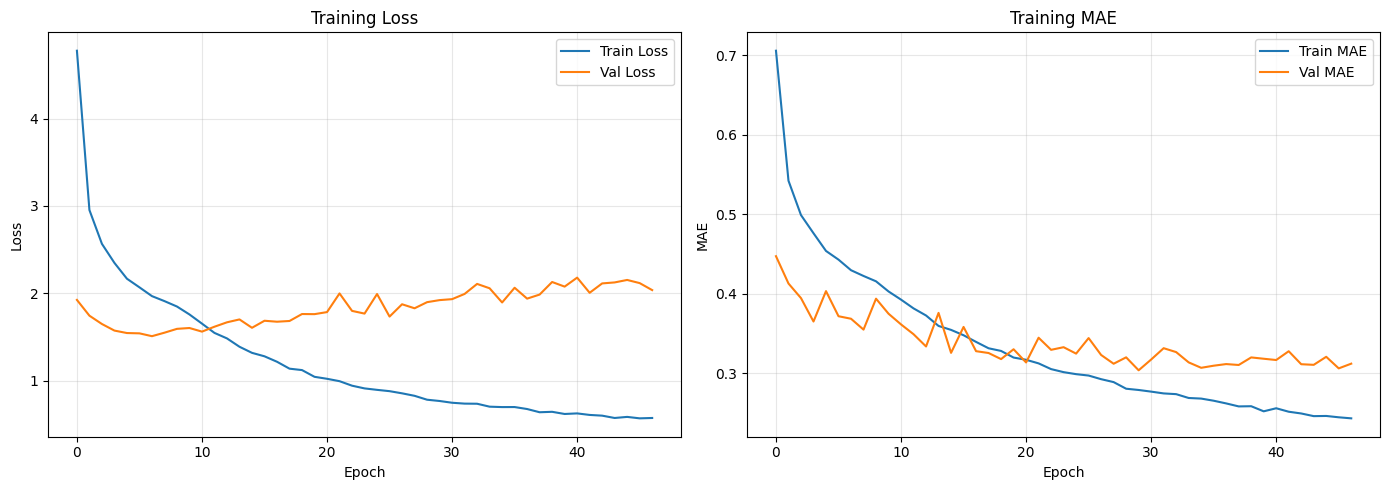

Final: train_loss=0.572189, val_loss=2.036179


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch'), axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss'), axes[0].legend(), axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_xlabel('Epoch'), axes[1].set_ylabel('MAE')
axes[1].set_title('Training MAE'), axes[1].legend(), axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final: train_loss={history.history['loss'][-1]:.6f}, val_loss={history.history['val_loss'][-1]:.6f}")

## Model Evaluation

In [27]:
start_time = time.time()
y_pred_scaled = model.predict(X_test_seq)
prediction_time = time.time() - start_time

y_pred_metrics = scaler_y.inverse_transform(y_pred_scaled)
y_test_metrics = scaler_y.inverse_transform(y_test_seq)

print(f"Predictions: {y_pred_metrics.shape} in {prediction_time:.4f}s ({prediction_time/len(X_test_seq)*1000:.2f} ms/sample)")

202/202 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
Predictions: (6450, 3) in 3.2193s (0.50 ms/sample)


In [28]:
HPA_CONFIG = {
    "target_rps_per_pod": 65.0, "target_cpu_util": 55.0, "min_pods": 1, "max_pods": 50,
    "bias_pods": 0.25, "hysteresis_fraction": 0.08, "scale_down_step": 1,
    "latency_slo_ms": 180.0, "latency_weight": 0.35, "ema_alpha": 0.25
}


def _ema(series, alpha):
    out = np.zeros_like(series, dtype=float)
    if len(series) == 0:
        return out
    out[0] = series[0]
    for i in range(1, len(series)):
        out[i] = alpha * series[i] + (1 - alpha) * out[i-1]
    return out


def compute_pod_count(pred_rps, pred_cpu, pred_latency, current_pods, cfg):
    """HPA-style pod count computation."""
    pred_rps = max(0.0, float(pred_rps))
    pred_cpu = float(np.clip(pred_cpu, 0.0, 100.0))
    current_pods = max(cfg["min_pods"], int(current_pods))

    desired_rps = math.ceil(pred_rps / cfg["target_rps_per_pod"])
    desired_cpu = math.ceil(current_pods * (pred_cpu / cfg["target_cpu_util"]))
    desired = max(desired_rps, desired_cpu)

    if cfg.get("latency_slo_ms") and pred_latency:
        latency_ratio = max(0.0, (pred_latency - cfg["latency_slo_ms"]) / cfg["latency_slo_ms"])
        if latency_ratio > 0:
            desired = max(desired, math.ceil(desired * (1 + cfg["latency_weight"] * latency_ratio)))

    desired = max(cfg["min_pods"], min(cfg["max_pods"], math.ceil(desired + cfg["bias_pods"])))

    delta = abs(desired - current_pods) / max(current_pods, 1)
    if delta < cfg["hysteresis_fraction"]:
        desired = current_pods
    elif desired < current_pods:
        desired = max(cfg["min_pods"], current_pods - cfg["scale_down_step"])

    return desired


def compute_pod_counts_batch(pred_metrics, current_pods_array, cfg):
    preds = np.array(pred_metrics, dtype=float)
    if cfg.get("ema_alpha", 0) > 0:
        for i in range(3):
            preds[:, i] = _ema(preds[:, i], cfg["ema_alpha"])
    return np.array([compute_pod_count(preds[i, 0], preds[i, 1], preds[i, 2],
                                        current_pods_array[i], cfg) for i in range(len(preds))], dtype=int)

In [29]:
def calibrate_hpa(pred_metrics, current_pods_list, actual_pods, base_cfg):
    """Grid search for optimal HPA parameters."""
    search_space = {
        "target_rps_per_pod": [55.0, 60.0, 65.0, 70.0, 80.0],
        "target_cpu_util": [50.0, 55.0, 60.0, 65.0],
        "bias_pods": [0.0, 0.25, 0.5, 0.75, 1.0],
        "hysteresis_fraction": [0.0, 0.05, 0.08, 0.12],
    }
    best = None
    for alignment_name, current_pods in current_pods_list:
        for rps, cpu, bias, hyst in product(*search_space.values()):
            cfg = {**base_cfg, "target_rps_per_pod": rps, "target_cpu_util": cpu,
                   "bias_pods": bias, "hysteresis_fraction": hyst}
            preds = compute_pod_counts_batch(pred_metrics, current_pods, cfg)
            mae = mean_absolute_error(actual_pods, preds)
            if best is None or mae < best["mae"]:
                best = {"mae": mae, "alignment": alignment_name, "cfg": cfg, "preds": preds}
    return best

In [30]:
df_service_full = df[df['service_id'] == SERVICE_NAME].copy().sort_values('timestamp').reset_index(drop=True)
n_preds = len(y_pred_metrics)

# Alignment options
alignment_options = []
base = test_df['current_pod_count'].iloc[LOOKBACK:].values
if len(base) >= n_preds:
    alignment_options.append(("window_start", base[:n_preds]))

start_idx = train_size + val_size + LOOKBACK + PREDICTION_HORIZON
end_idx = start_idx + n_preds
y_test_pods = df_service_full['current_pod_count'].iloc[start_idx:end_idx].values

# Calibrate HPA
best = calibrate_hpa(y_pred_metrics, alignment_options, y_test_pods, HPA_CONFIG)
y_pred_pods = best['preds']

# Metrics
mae = mean_absolute_error(y_test_pods, y_pred_pods)
rmse = np.sqrt(mean_squared_error(y_test_pods, y_pred_pods))
mape = np.mean(np.abs((y_test_pods - y_pred_pods) / np.where(y_test_pods != 0, y_test_pods, 1))) * 100
r2 = r2_score(y_test_pods, y_pred_pods)

print(f"Pod Count - MAE: {mae:.4f}, RMSE: {rmse:.4f}, MAPE: {mape:.2f}%, R2: {r2:.4f}")
print(f"Within 0.5: {np.mean(np.abs(y_test_pods - y_pred_pods) <= 0.5)*100:.1f}%, "
      f"Within 1.0: {np.mean(np.abs(y_test_pods - y_pred_pods) <= 1.0)*100:.1f}%")

# Individual metrics
for i, name in enumerate(['RPS', 'CPU%', 'Latency']):
    m_mae = mean_absolute_error(y_test_metrics[:, i], y_pred_metrics[:, i])
    m_r2 = r2_score(y_test_metrics[:, i], y_pred_metrics[:, i])
    print(f"{name}: MAE={m_mae:.4f}, R2={m_r2:.4f}")

Pod Count - MAE: 0.6586, RMSE: 0.9491, MAPE: 16.09%, R2: 0.8456
Within 0.5: 43.4%, Within 1.0: 92.2%
RPS: MAE=29.2798, R2=0.6451
CPU%: MAE=3.9215, R2=0.3904
Latency: MAE=33.1324, R2=0.3299


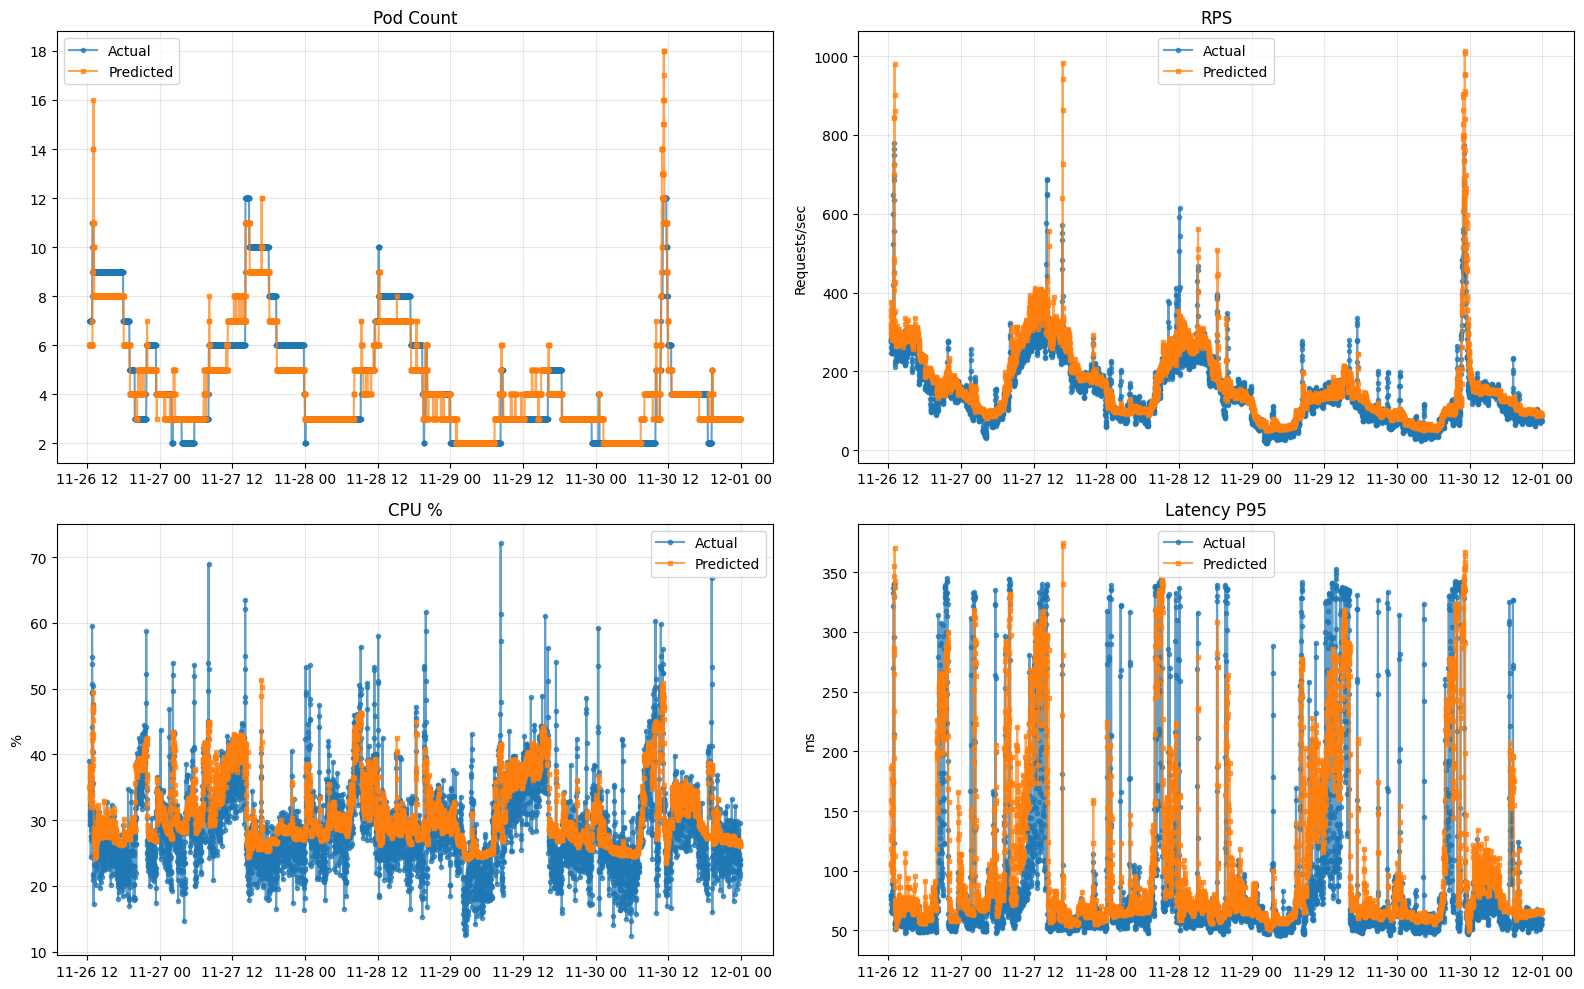

In [31]:
test_timestamps = test_df['timestamp'].iloc[LOOKBACK:].values

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(test_timestamps, y_test_pods, label='Actual', marker='o', markersize=3, alpha=0.7)
axes[0, 0].plot(test_timestamps, y_pred_pods, label='Predicted', marker='s', markersize=3, alpha=0.7)
axes[0, 0].set_title('Pod Count'), axes[0, 0].legend(), axes[0, 0].grid(True, alpha=0.3)

for idx, (ax, name, ylabel) in enumerate([(axes[0, 1], 'RPS', 'Requests/sec'),
                                           (axes[1, 0], 'CPU %', '%'),
                                           (axes[1, 1], 'Latency P95', 'ms')]):
    ax.plot(test_timestamps, y_test_metrics[:, idx], label='Actual', marker='o', markersize=3, alpha=0.7)
    ax.plot(test_timestamps, y_pred_metrics[:, idx], label='Predicted', marker='s', markersize=3, alpha=0.7)
    ax.set_title(name), ax.set_ylabel(ylabel), ax.legend(), ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

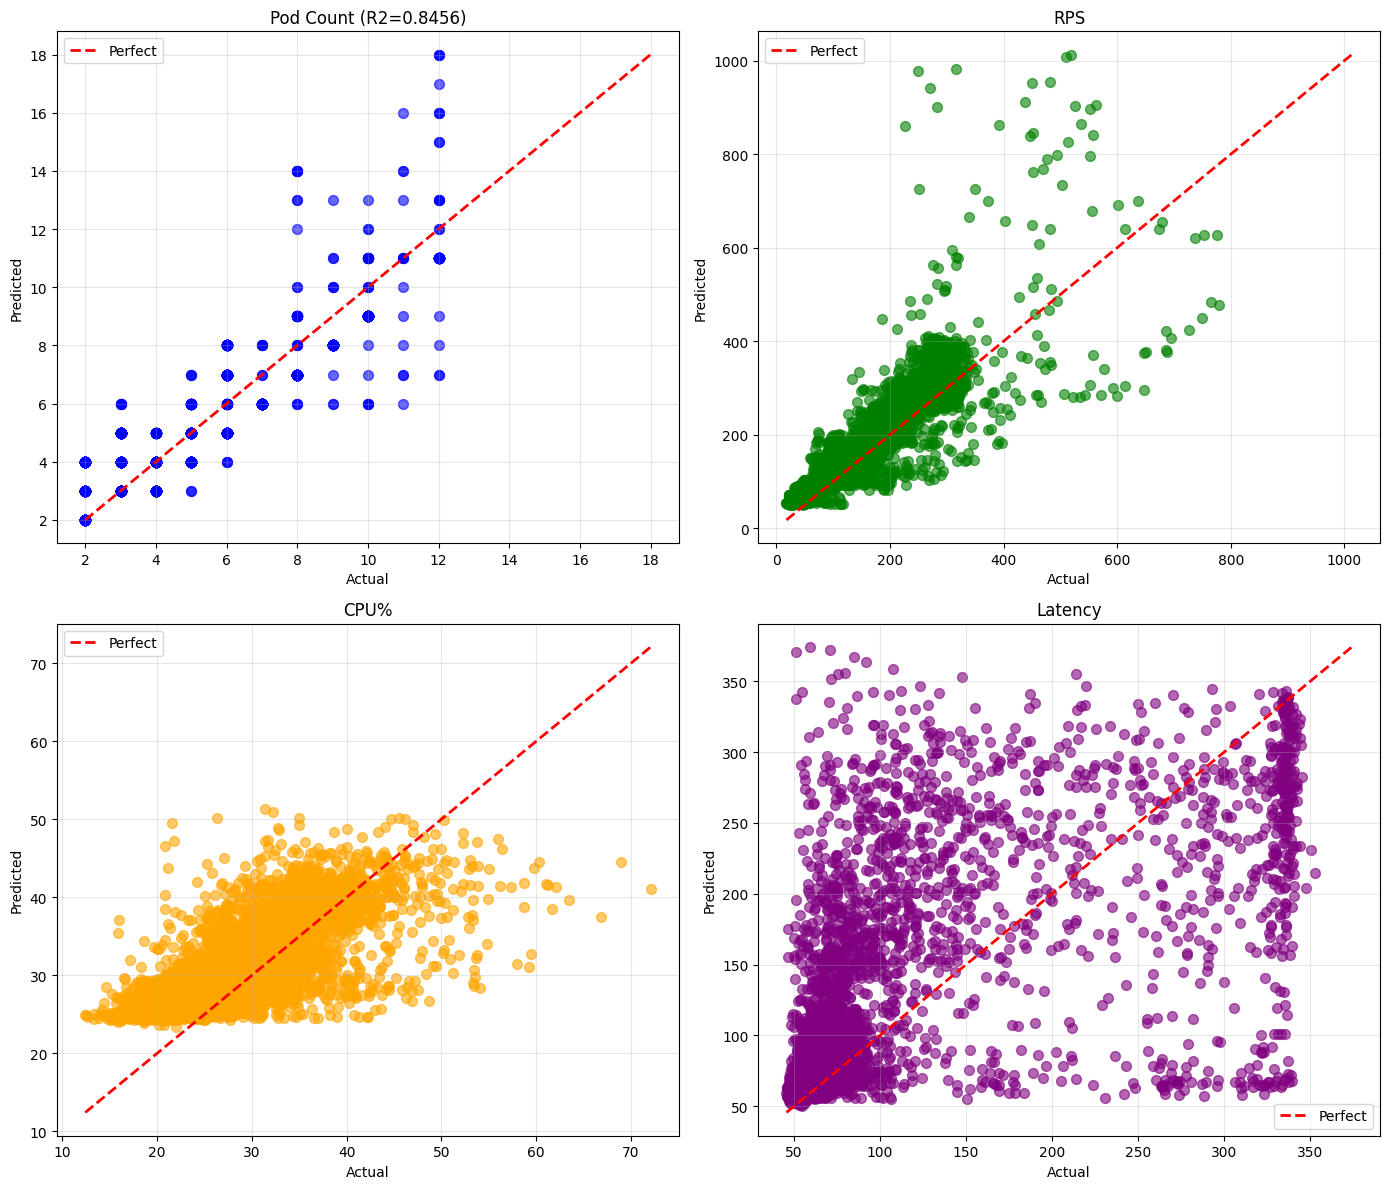

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for idx, (ax, y_true, y_pred, title, color) in enumerate([
    (axes[0, 0], y_test_pods, y_pred_pods, f'Pod Count (R2={r2:.4f})', 'blue'),
    (axes[0, 1], y_test_metrics[:, 0], y_pred_metrics[:, 0], 'RPS', 'green'),
    (axes[1, 0], y_test_metrics[:, 1], y_pred_metrics[:, 1], 'CPU%', 'orange'),
    (axes[1, 1], y_test_metrics[:, 2], y_pred_metrics[:, 2], 'Latency', 'purple')
]):
    ax.scatter(y_true, y_pred, alpha=0.6, s=50, color=color)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect')
    ax.set_xlabel('Actual'), ax.set_ylabel('Predicted'), ax.set_title(title)
    ax.legend(), ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

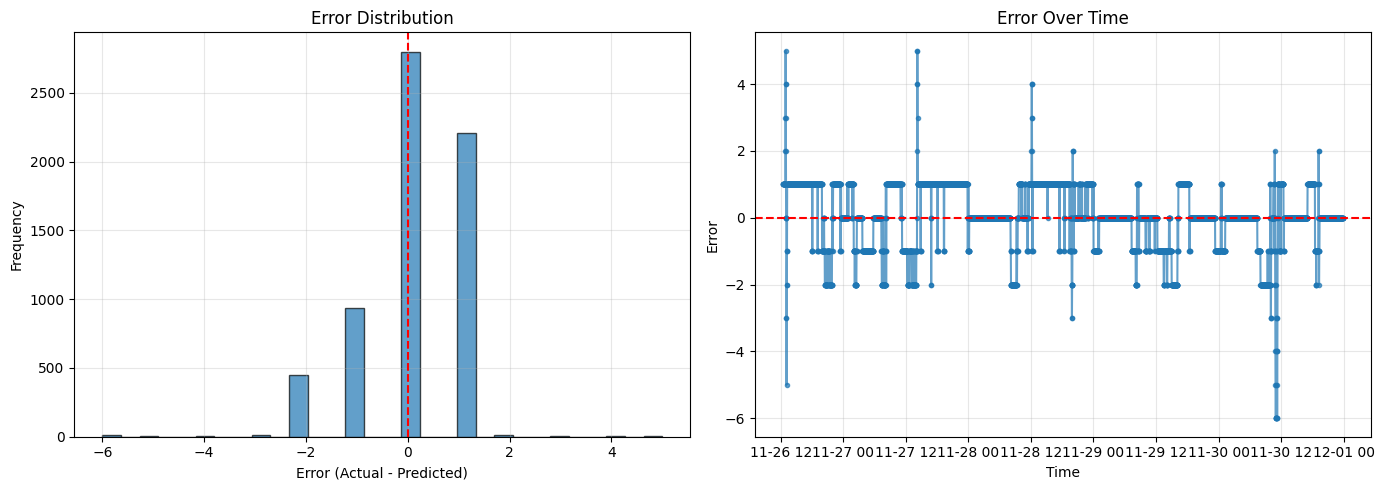

Error: mean=0.0515, std=0.9477, range=[-6.0000, 5.0000]


In [33]:
errors = y_test_pods.flatten() - y_pred_pods.flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(errors, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='r', linestyle='--')
axes[0].set_xlabel('Error (Actual - Predicted)'), axes[0].set_ylabel('Frequency')
axes[0].set_title('Error Distribution'), axes[0].grid(True, alpha=0.3)

axes[1].plot(test_timestamps, errors, marker='o', markersize=3, alpha=0.7)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Time'), axes[1].set_ylabel('Error')
axes[1].set_title('Error Over Time'), axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Error: mean={errors.mean():.4f}, std={errors.std():.4f}, range=[{errors.min():.4f}, {errors.max():.4f}]")

## Advanced Error Analysis

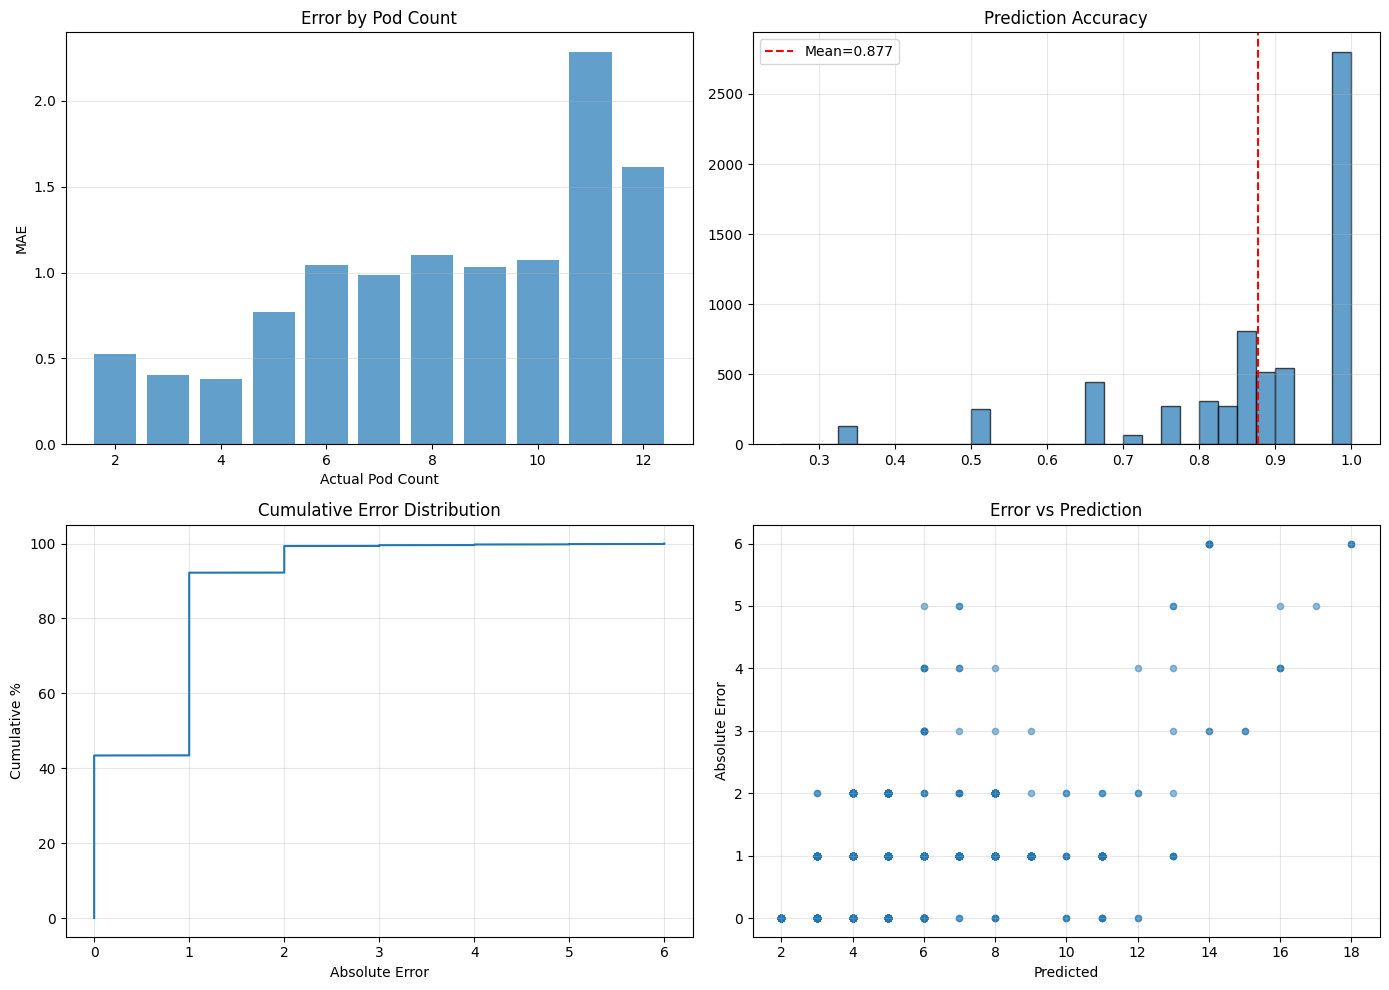

Percentiles - P50: 1.0000, P90: 1.0000, P99: 2.0000


In [34]:
error_by_pod = {v: np.abs(y_test_pods[y_test_pods == v] - y_pred_pods[y_test_pods == v]).mean()
                for v in np.unique(y_test_pods)}
errors = y_test_pods.flatten() - y_pred_pods.flatten()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(list(error_by_pod.keys()), list(error_by_pod.values()), alpha=0.7)
axes[0, 0].set_xlabel('Actual Pod Count'), axes[0, 0].set_ylabel('MAE')
axes[0, 0].set_title('Error by Pod Count'), axes[0, 0].grid(True, alpha=0.3, axis='y')

accuracy = 1 - np.abs(errors) / (y_test_pods.flatten() + 1)
axes[0, 1].hist(accuracy, bins=30, alpha=0.7, edgecolor='black')
axes[0, 1].axvline(x=accuracy.mean(), color='r', linestyle='--', label=f'Mean={accuracy.mean():.3f}')
axes[0, 1].set_title('Prediction Accuracy'), axes[0, 1].legend(), axes[0, 1].grid(True, alpha=0.3)

sorted_errors = np.sort(np.abs(errors))
cumulative = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors) * 100
axes[1, 0].plot(sorted_errors, cumulative)
axes[1, 0].set_xlabel('Absolute Error'), axes[1, 0].set_ylabel('Cumulative %')
axes[1, 0].set_title('Cumulative Error Distribution'), axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(y_pred_pods.flatten(), np.abs(errors), alpha=0.5, s=20)
axes[1, 1].set_xlabel('Predicted'), axes[1, 1].set_ylabel('Absolute Error')
axes[1, 1].set_title('Error vs Prediction'), axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Percentiles - P50: {np.percentile(np.abs(errors), 50):.4f}, P90: {np.percentile(np.abs(errors), 90):.4f}, P99: {np.percentile(np.abs(errors), 99):.4f}")

In [35]:
print("=" * 60)
print("FINAL PERFORMANCE SUMMARY")
print("=" * 60)
print(f"Pod Count - R2: {r2:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, MAPE: {mape:.2f}%")
print(f"Within 0.5: {np.mean(np.abs(y_test_pods - y_pred_pods) <= 0.5)*100:.1f}%, "
      f"Within 1.0: {np.mean(np.abs(y_test_pods - y_pred_pods) <= 1.0)*100:.1f}%")
print(f"\nTraining time: {training_time/60:.2f} min, Inference: {prediction_time/len(X_test_seq)*1000:.2f} ms/sample")
print(f"Parameters: {model.count_params():,}")

if r2 > 0.80 and mae < 0.50:
    print("\nModel ready for production")
elif r2 > 0.60:
    print("\nModel promising - consider tuning HPA parameters")
else:
    print("\nModel needs improvement - enable hyperparameter tuning")

FINAL PERFORMANCE SUMMARY
Pod Count - R2: 0.8456, MAE: 0.6586, RMSE: 0.9491, MAPE: 16.09%
Within 0.5: 43.4%, Within 1.0: 92.2%

Training time: 11.86 min, Inference: 0.50 ms/sample
Parameters: 1,109,763

Model promising - consider tuning HPA parameters


## Inference Function

In [36]:
def predict_pod_count(model, scaler_X, scaler_y, feature_cols, recent_data, lookback, hpa_cfg):
    """Predict pod count from recent telemetry data."""
    if len(recent_data) < lookback:
        raise ValueError(f"Need at least {lookback} rows, got {len(recent_data)}")

    recent_data = recent_data.tail(lookback).copy()
    X = scaler_X.transform(recent_data[feature_cols].values)
    X_seq = X.reshape(1, lookback, len(feature_cols))

    y_pred_scaled = model.predict(X_seq, verbose=0)
    y_pred_metrics = scaler_y.inverse_transform(y_pred_scaled)

    current_pod_count = recent_data.iloc[-1]['current_pod_count']
    pred_pods = compute_pod_count(y_pred_metrics[0, 0], y_pred_metrics[0, 1],
                                   y_pred_metrics[0, 2], current_pod_count, hpa_cfg)

    return {
        'predicted_pod_count': int(pred_pods),
        'predicted_rps': float(y_pred_metrics[0, 0]),
        'predicted_cpu': float(y_pred_metrics[0, 1]),
        'predicted_latency': float(y_pred_metrics[0, 2]),
        'current_pod_count': int(current_pod_count)
    }

In [37]:
example_data = test_df.tail(LOOKBACK + 1).copy()
current = example_data.iloc[-1]

print(f"Current: pods={current['current_pod_count']:.0f}, rps={current['request_rate_rps']:.1f}, "
      f"cpu={current['pod_cpu_usage_percent_avg']:.1f}%")

pred = predict_pod_count(model, scaler_X, scaler_y, feature_cols, example_data, LOOKBACK, best['cfg'])
print(f"Predicted ({PREDICTION_HORIZON}min ahead): pods={pred['predicted_pod_count']}, "
      f"rps={pred['predicted_rps']:.1f}, cpu={pred['predicted_cpu']:.1f}%")

Current: pods=3, rps=76.0, cpu=24.0%
Predicted (5min ahead): pods=3, rps=86.5, cpu=26.8%


In [38]:
print("Rolling Predictions (first 10 samples):")
print("-" * 80)

for i in range(min(10, len(test_df) - LOOKBACK - PREDICTION_HORIZON)):
    window = test_df.iloc[i:i + LOOKBACK + 1]
    pred = predict_pod_count(model, scaler_X, scaler_y, feature_cols, window, LOOKBACK, best['cfg'])

    actual_idx = i + LOOKBACK + PREDICTION_HORIZON
    actual = int(test_df.iloc[actual_idx]['current_pod_count']) if actual_idx < len(test_df) else None
    error = abs(pred['predicted_pod_count'] - actual) if actual else None

    print(f"{window.iloc[-1]['timestamp']}: curr={pred['current_pod_count']}, "
          f"pred={pred['predicted_pod_count']}, actual={actual}, err={error}")

Rolling Predictions (first 10 samples):
--------------------------------------------------------------------------------
2025-11-26 12:25:00: curr=7, pred=7, actual=7, err=0
2025-11-26 12:26:00: curr=7, pred=6, actual=7, err=1
2025-11-26 12:27:00: curr=7, pred=6, actual=7, err=1
2025-11-26 12:28:00: curr=7, pred=6, actual=7, err=1
2025-11-26 12:29:00: curr=7, pred=6, actual=7, err=1
2025-11-26 12:30:00: curr=7, pred=6, actual=7, err=1
2025-11-26 12:31:00: curr=7, pred=6, actual=7, err=1
2025-11-26 12:32:00: curr=7, pred=6, actual=7, err=1
2025-11-26 12:33:00: curr=7, pred=7, actual=7, err=0
2025-11-26 12:34:00: curr=7, pred=6, actual=7, err=1


## Baseline Comparison

In [39]:
# Persistence baseline
naive_pods = np.concatenate([[y_test_pods[0]], y_test_pods[:-1]])
naive_mae = mean_absolute_error(y_test_pods, naive_pods)
naive_r2 = r2_score(y_test_pods, naive_pods)

print("Baseline vs Model:")
print(f"  Naive (persistence): MAE={naive_mae:.4f}, R2={naive_r2:.4f}")
print(f"  Model:               MAE={mae:.4f}, R2={r2:.4f}")

pod_errors = y_pred_pods.flatten() - y_test_pods.flatten()
print(f"\nBias: {pod_errors.mean():.4f}, Under-pred: {(pod_errors < 0).mean()*100:.1f}%, Over-pred: {(pod_errors > 0).mean()*100:.1f}%")

# Error by load buckets
def bucket_stats(y_true, y_pred, name, bins=4):
    df_temp = pd.DataFrame({"true": y_true, "pred": y_pred})
    df_temp["bucket"] = pd.qcut(df_temp["true"], q=bins, duplicates="drop")
    stats = df_temp.groupby("bucket").apply(
        lambda g: pd.Series({"mae": mean_absolute_error(g["true"], g["pred"]),
                             "r2": r2_score(g["true"], g["pred"]) if len(g) > 1 else 0}))
    print(f"\n{name} by quantile:")
    print(stats)

for i, name in enumerate(['RPS', 'CPU%', 'Latency']):
    bucket_stats(y_test_metrics[:, i], y_pred_metrics[:, i], name)

Baseline vs Model:
  Naive (persistence): MAE=0.0167, R2=0.9956
  Model:               MAE=0.6586, R2=0.8456

Bias: -0.0515, Under-pred: 34.7%, Over-pred: 21.9%

RPS by quantile:
                         mae        r2
bucket                                
(17.589, 86.712]   21.459615 -1.074865
(86.712, 134.45]   18.869237 -2.333832
(134.45, 190.855]  21.237543 -3.382252
(190.855, 780.17]  55.542904 -0.453739

CPU% by quantile:
                      mae         r2
bucket                              
(12.419, 24.32]  5.429180  -6.973969
(24.32, 27.82]   2.909921 -14.098097
(27.82, 32.41]   2.794868  -8.039182
(32.41, 72.07]   4.546701  -0.451708

Latency by quantile:
                                    mae          r2
bucket                                             
(45.589000000000006, 55.902]  14.386915 -121.436454
(55.902, 62.19]               13.692635 -255.229403
(62.19, 79.678]               26.177273  -92.061590
(79.678, 352.94]              78.256555   -0.112685
